In this notebook, we consider a system of three nodes in a "V" formation, with
mass input into a single bottom node, which then feeds into two shallower
chambers asymmetrically.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import cnetwork
from cnetwork import MagmaChamber, GlobalSystemThreshold

First we set up the nodes with a fixed geometry:

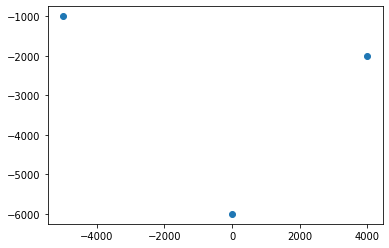

In [2]:
# Set reference density of melt
rhoref = 2500
# Set limits of characteristic size of chamber
R_ref = 1000
# Uniformly randomly distribution volume
V_ref = (4/3)*np.pi*R_ref**3

# Generate list of chambers
x_nodes = np.array([0,     -5000,  4000,])
y_nodes = np.array([0,     -0,     0,])
z_nodes = np.array([-6000, -1000,  -2000,])
V_nodes = np.array([4.0,    0.25,  1 ]) * V_ref
list_nodes = [MagmaChamber(x=x, y=y, z=z,
  p_setting=None, vref=1.0/rhoref,
  T_setting=1000+273.15, V_setting=V)
  for (x,y,z,V) in zip(x_nodes, y_nodes, z_nodes, V_nodes)]
plt.scatter(x_nodes, z_nodes)

Here we define the global system, including injection rate and potential eruption rates.

In [147]:
# Set up system with default properties
props = cnetwork.default_props(
  t_d_default=1e9,
  t_b_default=1e9,
  r_hydr_default=100,
  )
global_sys = GlobalSystemThreshold(list_nodes,
  **props,
  **cnetwork.default_numerics(),
  dpdx_crit=1e3, dpdx_threshold_scale=1e2, max_edge_dist=np.inf,
  residual_overpressure=0, # -2.5e6,
  always_max_eruption_rate=True)

# Source term due to eruption at node -1
f_erupt = global_sys.create_eruptible_layer(
  p_erupt_min=5e6, p_erupt_max=5e6,
  z_min=-2200, z_max=0.0, mu_erupt=1e5, r_conduit=25)

# Define multiple injections
# mdot_inj1 = 0.3 # SET 1
# mdot_inj2 = 0.6 # SET 1
mdot_inj1 = .2e-10 * V_ref * rhoref
# mdot_inj2 = 6.0e-10 * V_ref * rhoref

def f_inj_multiple(t, q):
  ''' Constant mass rate injection at node indices 0 and 1. '''
  f_inj = np.zeros((global_sys.num_dof))
  # return f_inj
  if True:
  # if t < .1e10:
  # if t < .5e10:
    f_inj[global_sys.data_slice_global(0, "mass")] = mdot_inj1
  # f_inj[global_sys.data_slice_global(1, "mass")] = mdot_inj2
  return f_inj

def f_inj_ramp(t, q, max_rate=2e-11 * V_ref * rhoref,
               ramp_time=10e9, inject_node_idx=0):
  ''' Constant mass rate injection at node indices 0 and 1.
  Ramp function
  '''
  f_inj = np.zeros((global_sys.num_dof))
  if ramp_time == 0:
    mdot_inj = max_rate
  else:
    mdot_inj = max_rate * np.clip(t / ramp_time, 0.0, 1.0)

  f_inj[global_sys.data_slice_global(inject_node_idx, "mass")] = mdot_inj

  return f_inj

In [ ]:
# Run the simulation
t_vec = np.linspace(0, 2000e7, 20000)
q_out, m_erupted_out = global_sys.simulation(global_sys.q0, t_vec,
                                             f_inj_ramp, f_erupt)
m, p, u = global_sys.compute_m_p_u(q_out)

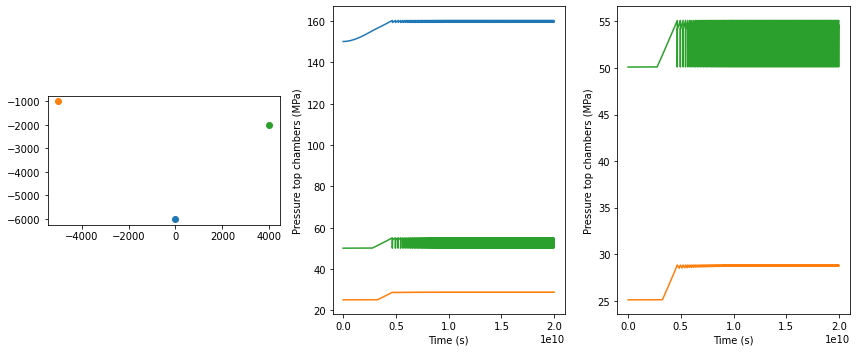

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
N_chambers = len(x_nodes)
for i in range(N_chambers):
  plt.scatter(x_nodes[i], z_nodes[i], c=color_cycle[i])
plt.gca().set_aspect('equal')

plot_idx = 200000

plt.subplot(1,3,2)
# plt.subplot(1,3,3)
for i in range(3):
  plt.plot(t_vec[:plot_idx], p[:,i][:plot_idx] / 1e6, color=color_cycle[i])
plt.xlabel("Time (s)")
plt.ylabel("Pressure top chambers (MPa)")
plt.tight_layout()

# plt.subplot(1,3,3)
plt.subplot(1,3,3)
for i in range(1,3):
  plt.plot(t_vec[:plot_idx], p[:,i][:plot_idx] / 1e6, color=color_cycle[i])
plt.xlabel("Time (s)")
plt.ylabel("Pressure top chambers (MPa)")
plt.tight_layout()

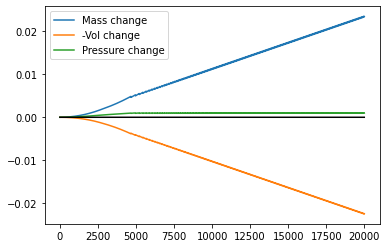

In [ ]:
# Show node 0 history: pressurization vs. volume decrease and mass increase
nodes = global_sys.nodes
dm = (m[:,0] / nodes[0].m0 - 1)
dV = 3 * u[:,0] / nodes[0].R0
dp = (p[:,0] - nodes[0].p_init) / nodes[0].K_f
plt.plot(dm, label="Mass change")
plt.plot(-dV, label="-Vol change")
plt.plot(dp, label="Pressure change")
plt.plot(-dp + dm - dV, 'k')
plt.legend()


Recharge/eruption space

By varying the eruption criteria and mass injection rate, how does the eruption site vary? Can we map locations in parameter space to different types of magma chamber cooperation (e.g., chamber 1 and chamber 2 both erupt, or chamber 1 recharges chamber 2)?

In [ ]:
# Independent variables for mapping
# relative_rates = np.geomspace(1e-11, 100e-11, 14)
# relative_rates = np.linspace(1e-11, 100e-11, 18)
relative_rates = np.linspace(1e-10, 5e-10, 24)
contrast_vec = np.linspace(1, 1.5, 8)
mg_rates, mg_contrast = np.meshgrid(relative_rates, contrast_vec)
outputs = np.empty_like(mg_rates, dtype=object)

# Eruption contrast
for (i, j), _ in np.ndenumerate(mg_rates):
  relative_rate = mg_rates[i,j]
  contrast = mg_contrast[i,j]

  # Set up fixed parameters
  t_vec = np.linspace(0, 100e7, 5000)
  # t_vec = np.linspace(0, 100e7, 40000)
  ramp_time = 0.0

  # Set up varying parameters
  p_erupt_min = 5e6
  max_rate = relative_rate * V_ref * rhoref
  f_erupt = global_sys.create_eruptible_layer(
    p_erupt_min=p_erupt_min,
    p_erupt_max=contrast*p_erupt_min,
    z_min=global_sys.nodes[2].z,
    z_max=global_sys.nodes[1].z,
    mu_erupt=1e5, r_conduit=25)

  q_out, m_erupted_out = global_sys.simulation(global_sys.q0, t_vec,
    lambda t, q: f_inj_ramp(t, q, max_rate=max_rate, ramp_time=ramp_time),
    f_erupt)
  m, p, u = global_sys.compute_m_p_u(q_out)

  m_eruption_by_chamber = np.array([
    -f_erupt(t_vec[i], q_out[i,:])[global_sys.mass_indices]
    for i, t in enumerate(t_vec)])
  
  outputs[i,j] = (m_eruption_by_chamber, m, p, u,)

In [363]:
# Restack outputs as n-d arrays of shape (n_contrast_cases, n_rate_cases, n_time, n_chambers)
_m_eruption_by_chamber, _m, _p, _u = zip(*outputs.ravel())
export_m_eruption_by_chamber = np.reshape(np.stack(_m_eruption_by_chamber, axis=0),
           (*outputs.shape, *_m_eruption_by_chamber[0].shape))
export_m = np.reshape(np.stack(_m, axis=0),
           (*outputs.shape, *_m[0].shape))
export_p = np.reshape(np.stack(_p, axis=0),
           (*outputs.shape, *_p[0].shape))
export_u = np.reshape(np.stack(_u, axis=0),
           (*outputs.shape, *_u[0].shape))
# np.savez_compressed("fig_V_output.npz",
#                     m_eruption_by_chamber=export_m_eruption_by_chamber,
#                     m=export_m,
#                     p=export_p,
#                     u=export_u,
#                     )

Plots of eruption rates by chamber: 


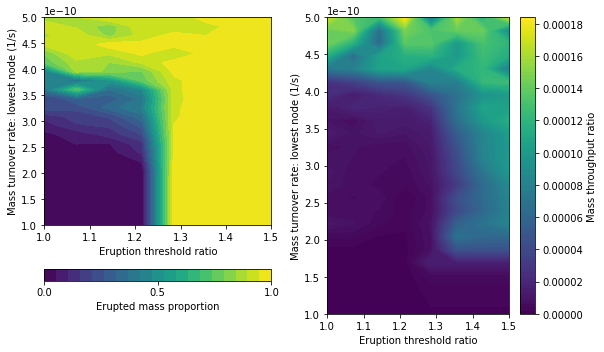

In [335]:
# For each output, sum over time to compute total mass erupted per node
mg_mass_out = np.reshape(np.stack([
  output[0].sum(axis=0) for output in outputs.ravel()],
  axis=0), (*mg_contrast.shape,-1))

plot_individual_masses = False
if plot_individual_masses:
  plt.subplots(figsize=(8.5,5))
  plt.subplot(1,2,1)
  plt.contourf(mg_contrast, mg_rates, np.log10(mg_mass_out[:,:,1]))
  plt.colorbar()
  plt.subplot(1,2,2)
  plt.contourf(mg_contrast, mg_rates, np.log10(mg_mass_out[:,:,2]))
  plt.colorbar()

  plt.xlabel("Eruption threshold ratio")
  plt.ylabel("Mass turnover rate: lowest node (1/s)")

# Compute mass partition
total_mass = mg_mass_out[:,:,:].sum(axis=-1, keepdims=True)
eruption_partition = mg_mass_out / total_mass
throughput_efficiency = total_mass / ((t_vec[-1] - t_vec[0]) * max_rate)

plt.subplots(figsize=(8.5,5))
plt.subplot(1,2,1)
plt.contourf(mg_contrast, (mg_rates), eruption_partition[:,:,1],
  levels=np.linspace(0, 1, 20))
plt.xlabel("Eruption threshold ratio")
plt.ylabel("Mass turnover rate: lowest node (1/s)")
plt.colorbar(label="Erupted mass proportion", location="bottom", ticks=[0, 0.5, 1.0])
plt.subplot(1,2,2)
plt.contourf(mg_contrast, mg_rates, throughput_efficiency.squeeze(),
             levels=100)
plt.xlabel("Eruption threshold ratio")
plt.ylabel("Mass turnover rate: lowest node (1/s)")
plt.colorbar(label="Mass throughput ratio")

plt.tight_layout()

print("Plots of eruption rates by chamber: ")

1.2142857142857142 ,  3e-10


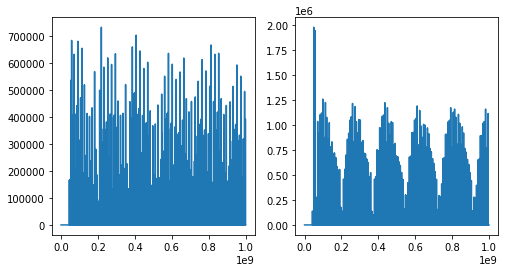

In [331]:
# Select a specific case
i, j = 3, 2
print(mg_contrast[i,j], ", ", mg_rates[i,j])
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(t_vec, outputs[i,j][0][:,1])
plt.subplot(1,2,2)
plt.plot(t_vec, outputs[i,j][0][:,2])


Legacy code

In [ ]:
# ''' Peak picking '''
# # Take data series
# series = p[:,2][:plot_idx] / 1e6

# # Compute boolean values corresponding to sign changes
# is_peak = (np.diff(series[1:]) > 0).astype(float) * (np.diff(series[:-1]) < 0).astype(float)
# # First time data is over 99% of the max
# first_index = np.argmax(series > 0.99 * series.max())
# # Compute indices where peak is detected in data series
# peak_indices = (first_index + 1 + np.where(is_peak[first_index:])).squeeze()
# plt.plot(t_vec[peak_indices], '.')
# plt.xlabel("Local peak number")
# plt.ylabel("Time of occurence (s)")